## Datasets and Dataloaders

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:02<00:00, 10.1MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 1.13MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:00<00:00, 9.15MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 1.26MB/s]


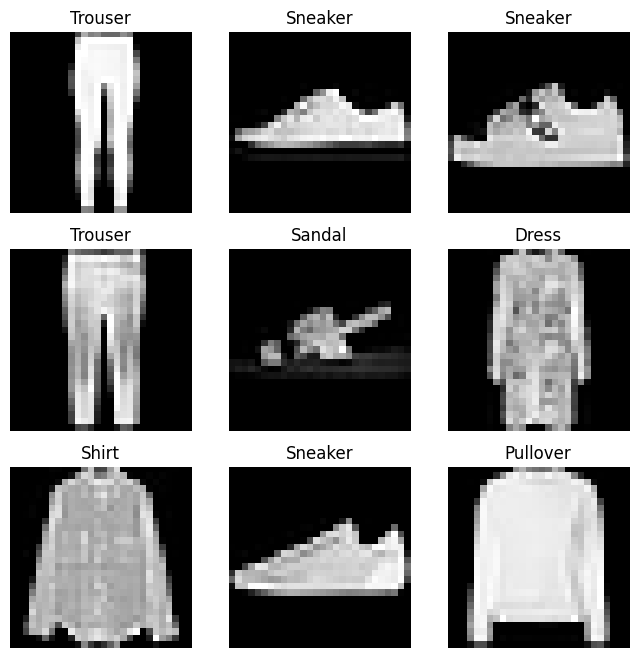

In [7]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Custom Dataset class

In [8]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, traget_transform=None):
        self.img_lables = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = traget_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path) # converts image to tensor
        if self.transform:
            image = self.transform(image)
        if self.traget_transform:
            label = self.target_transform(label)
        return image, label

### DataLoader

In [9]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


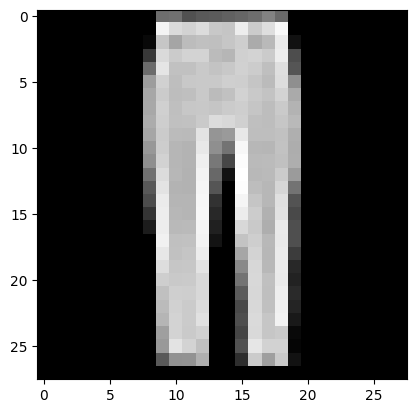

lable: Trouser


In [18]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze() # Returns a tensor with all specified dimensions of input of size 1 removed.
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"label: {labels_map[label.item()]}")

### Transforms

All TorchVision datasets have two parameters -transform to modify the features and target_transform to modify the labels - that accept callables containing the transformation logic. 

In [19]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

New labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


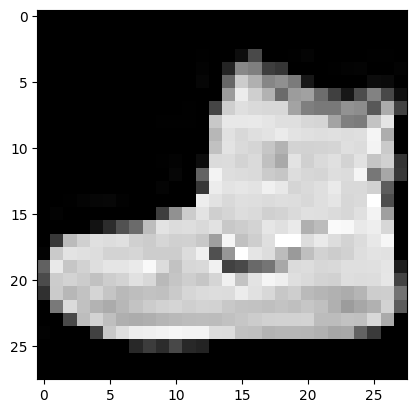

In [22]:
img, label = ds[0]
plt.imshow(img.squeeze(), cmap="gray")
print(f"New labels: {label}")

## Loading Data

#### Loading Image Data

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("heavensky/image-dataset-for-unsupervised-clustering")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

### Loading Tabular Data

Samples to load and use tabular data as from csv. Examplified using a wine-quality csv dataset.

#### Data Pre-processing for Tabular data
1. Read the data -> split in input (X) and target (y) -> transform
Transform:
```
Column contians -> continous data -Yes-> Use values directly
                -> ordinal data -Yes-> ordering priority? -Yes-> Treat as continous
                                                          -No-> Treat as categorical     
                -> categroical data -Yes-> Use one-hot or embedding 
```

In [42]:
import torch
import numpy as np
import csv

path = "./data/wine-quality.csv"

wine_quality_numpy = np.loadtxt(path, dtype=np.float32, delimiter=";", skiprows=1)
wine_quality_torch = torch.from_numpy(wine_quality_numpy)

col_list = next(csv.reader(open(path), delimiter=';')) # column names

data = wine_quality_torch[:, :-1] # Input data for the model is every columns expect the last.
target = wine_quality_torch[:, -1].long() # All rows form the last column

print(f"List of unique labels from wine_quality targets: {np.unique(target.numpy())}")

List of unique labels from wine_quality targets: [3 4 5 6 7 8 9]


In [33]:
target_onehot = torch.zeros(target.shape[0], 10)
target_onehot.scatter_(1, target.unsqueeze(1), 1)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

### Data Analysis Techniques

Filtering data using the target value - What makes the target value?

In [40]:
data_mean = torch.mean(data, dim=0)
data_var = torch.var(data, dim=0)
data_normalized = (data - data_mean) / torch.sqrt(data_var) # basic normalization technique
bad_indexes = target <= 3 # building up a mask that filters every low quality score
data_normalized[bad_indexes] # print only the values with good quality
print(f"Without mask {data_normalized.shape}, with mask {data_normalized[bad_indexes].shape}")

Without mask torch.Size([4898, 11]), with mask torch.Size([20, 11])


In [56]:
bad_data = data[target <= 3]
mid_data = data[(target > 3) & (target < 7)]
good_data = data[target >= 7]

bad_mean = torch.mean(bad_data, dim=0)
mid_mean = torch.mean(mid_data, dim=0)
good_mean = torch.mean(good_data, dim=0)
print(" i, Column,               bm,   mm,    gm")
for i, args in enumerate(zip(col_list, bad_mean, mid_mean, good_mean)):
    print('{:2} {:20} {:6.2f} {:6.2f} {:6.2f}'.format(i, *args))

 i, Column,               bm,   mm,    gm
 0 fixed acidity          7.60   6.89   6.73
 1 volatile acidity       0.33   0.28   0.27
 2 citric acid            0.34   0.34   0.33
 3 residual sugar         6.39   6.71   5.26
 4 chlorides              0.05   0.05   0.04
 5 free sulfur dioxide   53.33  35.42  34.55
 6 total sulfur dioxide 170.60 141.83 125.25
 7 density                0.99   0.99   0.99
 8 pH                     3.19   3.18   3.22
 9 sulphates              0.47   0.49   0.50
10 alcohol               10.34  10.26  11.42


Test the filter/threshold assumption

In [57]:
total_sulfur_threshold = 141.83
total_sulfur_data = data[:,6]
predicted_indexes = torch.lt(total_sulfur_data, total_sulfur_threshold)
predicted_indexes.shape, predicted_indexes.dtype, predicted_indexes.sum

actual_indexes = target > 5
actual_indexes.shape, actual_indexes.dtype, actual_indexes.sum()

(torch.Size([4898]), torch.bool, tensor(2727))

### Loading Time Series Data
Previously in the Loading Tabular Data section we were loading unordered data but some datasets like the bike-sharing system reporting provides time dependent data.

In [8]:
import numpy as np
import torch

bike_dataset = np.loadtxt(
    'data/hour.csv',
    dtype=np.float32,
    delimiter=",",
    skiprows=1,
    converters={1: lambda x: float(x[8:10])}
)
bikes = torch.from_numpy(bike_dataset)
bikes.shape, bikes.stride() # Rep: PyTorch needs to move 16 elements to get to the next row thats why stride is 16

(torch.Size([17379, 17]), (17, 1))

Since the current tensor size is 17379 we can't compute 24 hours per day 3D tensor, since (17379 * 17) % (24 * 17) != 0.

#### Tensor size transformation

In [16]:
if (bikes.shape[0] * bikes.shape[1]) % (24 * bikes.shape[1]) != 0:
    padding_size = 17520 - bikes.shape[0] # Next possible divisior, hard coded can be found dynamically
    pads = torch.zeros(padding_size, bikes.shape[1])
    bikes = torch.cat((bikes, pads), 0)

torch.Size([17520, 17])

In [17]:
daily_bikes = bikes.view(-1, 24, bikes.shape[1]) # where -1 is the inferred size of the tensor
daily_bikes.shape, daily_bikes.stride() # 17520 / 24 * 17 = 42

(torch.Size([730, 24, 17]), (408, 17, 1))

In [18]:
daily_bikes = daily_bikes.transpose(1,2)
daily_bikes.shape, daily_bikes.stride()

(torch.Size([730, 17, 24]), (408, 1, 17))

We transform the weather data into one-hot-encoded vecotr and concatenate the columns with the dataset.

In [29]:
first_day = bikes[:24].long()
weather_onehot = torch.zeros(first_day.shape[0], 4)
weather_onehot.scatter_(dim=1,index=first_day[:,9].unsqueeze(1).long() - 1,value=1.0)
# Concate to the previous dataset
torch.cat((bikes[:24], weather_onehot), 1)[:1]

tensor([[ 1.0000,  1.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  6.0000,
          0.0000,  1.0000,  0.2400,  0.2879,  0.8100,  0.0000,  3.0000, 13.0000,
         16.0000,  1.0000,  0.0000,  0.0000,  0.0000]])

#### Tensor value scaling

Transform the weather parameter so that the variable runs from 0.0 to 1.0.

In [33]:
daily_bikes[:, 9, :] = (daily_bikes[:, 9, :] - 1.0) / 3.0

tensor([[-0.4815, -0.4815, -0.4815,  ..., -0.4691, -0.4691, -0.4691],
        [-0.4691, -0.4691, -0.4691,  ..., -0.4815, -0.4815, -0.4815],
        [-0.4815, -0.4815, -0.4815,  ..., -0.4815, -0.4815, -0.4815],
        ...,
        [-0.4938, -0.4938, -0.4938,  ..., -0.4938, -0.4938, -0.4938],
        [-0.4938, -0.4938, -0.4938,  ..., -0.4938, -0.4938, -0.4938],
        [-0.4938, -0.4938, -0.4938,  ..., -0.4938, -0.4938, -0.4938]])

Map the range to `[0.0, 1.0]`

In [36]:
temp = daily_bikes[:, 10, :]
temp_min = torch.min(temp)
temp_max = torch.max(temp)
daily_bikes[:, 10, :] = ((daily_bikes[:, 10, :] - temp_min) / (temp_max - temp_min))

### Loading Text Data
Representing text as data a neural network can process in pytorch.

#### One-hot encodings

In [4]:
with open('./data/pride-and-perjudice.txt', encoding='utf8') as f:
    text = f.read()

In [5]:
lines = text.split('\n')
line = lines[200]
line

'own, such as her satire of Mrs. Musgrove’s self-deceiving regrets over'

In [6]:
import torch
letter_t = torch.zeros(len(lines), 128) # 128 hard-coded due to ascii limits.

for i, letter in enumerate(line.lower().strip()):
    letter_index = ord(letter) if ord(letter) < 128 else 0
    letter_t[i][letter_index] = 1

letter_t

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

Now one-hot encoding for whole words

In [7]:
def clean_words(input_str):
    punctuation = '.,;:"!?”“_-'
    word_list = input_str.lower().replace('\n',' ').split()
    word_list = [word.strip(punctuation) for word in word_list]
    return word_list

words_in_line = clean_words(line)
line, words_in_line

('own, such as her satire of Mrs. Musgrove’s self-deceiving regrets over',
 ['own',
  'such',
  'as',
  'her',
  'satire',
  'of',
  'mrs',
  'musgrove’s',
  'self-deceiving',
  'regrets',
  'over'])

In [8]:
word_list = sorted(set(clean_words(text)))
word2index_dict = {word: i for (i, word) in enumerate(word_list)}
len(word2index_dict), word2index_dict['impossible']

(7465, 3455)

In [9]:
word_t = torch.zeros(len(words_in_line), len(word2index_dict))
for i, word in enumerate(words_in_line):
    word_index = word2index_dict[word]
    word_t[i][word_index] = 1
    print('{:2} {:4} {}'.format(i, word_index, word))
print(word_t.shape)

 0 4744 own
 1 6406 such
 2  576 as
 3 3235 her
 4 5795 satire
 5 4618 of
 6 4395 mrs
 7 4401 musgrove’s
 8 5908 self-deceiving
 9 5489 regrets
10 4712 over
torch.Size([11, 7465])


#### Embeddings

Embeddings include words that live in an n-dimensional space where a certain range provides the type of a word, like adjective, noun etc. for example [0, 0.33] Every word is considered as noun etc. Embeddings are learned by a neural network.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)
word_to_ix = {"hello": 0, "world": 1}
embeds = nn.Embedding(2, 5)  # 2 words in vocab, 5 dimensional embeddings
lookup_tensor = torch.tensor([word_to_ix["hello"]], dtype=torch.long)
hello_embed = embeds(lookup_tensor)
print(hello_embed)

tensor([[ 0.6614,  0.2669,  0.0617,  0.6213, -0.4519]],
       grad_fn=<EmbeddingBackward0>)


## Build the neural network
Neural networks comprise of layers/modules that perform operations on data. The torch.nn namespace provides all the building blocks you need to build your own neural network. Every module in PyTorch subclasses the nn.Module. A neural network is a module itself that consists of other modules (layers). This nested structure allows for building and managing complex architectures easily.

In [23]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [24]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [25]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [26]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

In [27]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-0.0183, -0.0138, -0.0329,  ..., -0.0325, -0.0022,  0.0268],
        [-0.0326,  0.0327,  0.0080,  ...,  0.0158,  0.0115, -0.0012]],
       grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([ 0.0321, -0.0213], grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0180, -0.0429,  0.0393,  ...,  0.0415,  0.0135, -0.0187],
        [-0.0345,  0.0376, -0.0215,  ...,  0.0060, -0.0305,  0.0027]],
       grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.bias | 

## Build a Linear Model
The book Deep Learning with PyTorch provides us with some guidance on how to build a simple linear model, each subsection represents one step which to use.

### Gather the data

In [13]:
import torch
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0] # Tempratures in celcius
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4] # unknown units
tensor_c = torch.tensor(t_c)
tensor_u = torch.tensor(t_u)

### Visualize the data for debugging

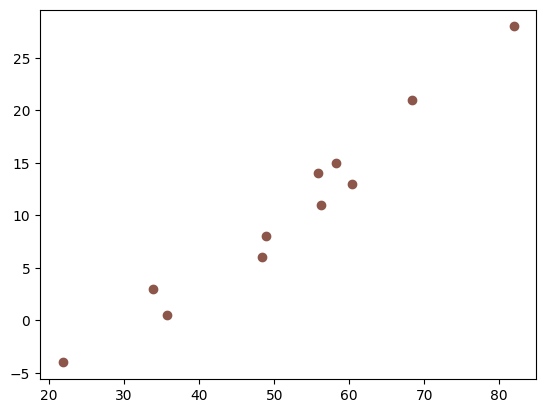

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(tensor_u, tensor_c, 'o', color="tab:brown")

### Choose a simple model to fit the data

Create a simple linear classifier/regression model by the following function

In [21]:
def model(tensor_u, w, b):
    return w * tensor_u + b

def loss_fn(tensor_p, tensor_c):
    squared_diffs = (tensor_p - tensor_c)**2
    return squared_diffs.mean()

### Split the data in training and validation

We use pytorchs `randperm` to gather a split indices. We need four items, 2 train and 2 val each one target and one input set.

In [42]:
n_samples = tensor_u.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_t_u = tensor_u[train_indices]
train_t_c = tensor_c[train_indices]

val_t_u = tensor_u[val_indices]
val_t_c = tensor_c[val_indices]

# Normalize
train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

### Train the "simple model"

In [22]:
params = torch.tensor([1.0, 0.0], requires_grad=True) # All computations with this tensor are tracked
loss = loss_fn(model(tensor_u, *params), tensor_c)
loss.backward()
params.grad

tensor([4517.2964,   82.6000])

Since the backward() function accumulates the gradient over times calling, we need to set it to zero after each call.

In [24]:
if params.grad is not None:
    params.grad.zero_()

Building blocks of a trianing loop; predict (train and validation), compute loss, zeroing gradient, backpropagate loss, compute step update

In [50]:
from torch import optim
# normalizing first so that the inputs so that the gradients arent quite so different

def training_loop(train_t_c, train_t_u, va_t_c, val_t_u, params, num_epochs=3000, lr=0.01, loss_fn=loss_fn):
    optimizer = optim.Adam([params], lr=lr)
    for epoch in range(1, num_epochs + 1):
        if params.grad is not None:
            params.grad.zero_()

        train_p = model(train_t_u, *params)
        train_loss = loss_fn(train_p, train_t_c)

        val_p = model(val_t_u, *params)
        val_loss = loss_fn(val_p, val_t_c)
            
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            params -= lr * params.grad

        if epoch <= 3 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
            f" Validation loss {val_loss.item():.4f}")
    return params

training_loop(
    train_t_c=train_t_c, 
    train_t_u=train_t_un, 
    va_t_c=val_t_c, 
    val_t_u=val_t_un,
    params= torch.tensor([1.0, 0.0], requires_grad=True),
    lr=1e-2,
    loss_fn=loss_fn
)

Epoch 1, Training loss 93.9443, Validation loss 19.2545
Epoch 2, Training loss 42.8809, Validation loss 0.8144
Epoch 3, Training loss 35.4073, Validation loss 5.2046
Epoch 500, Training loss 4.9122, Validation loss 4.5052
Epoch 1000, Training loss 3.0377, Validation loss 3.4978
Epoch 1500, Training loss 2.9704, Validation loss 3.3300
Epoch 2000, Training loss 2.9692, Validation loss 3.3069
Epoch 2500, Training loss 2.9692, Validation loss 3.3047
Epoch 3000, Training loss 2.9692, Validation loss 3.3046


tensor([  5.3905, -17.1046], requires_grad=True)

### Validate on the validation split

## Automatic Differentiation with `torch.autograd`

In [34]:
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x7bfa27645600>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x7bfa277300d0>


In [35]:
print(f"w: {w}")
print(f"b: {b}")
loss.backward()
print(f"w grad: {w.grad}")
print(f"b grad: {b.grad}")

w: tensor([[-0.5605,  0.7936, -0.1377],
        [-1.9830, -0.9266, -0.7075],
        [-0.0709,  0.3309,  0.6170],
        [ 1.7163,  0.5623, -0.4097],
        [ 0.3733, -0.6621,  0.6185]], requires_grad=True)
b: tensor([-1.1124, -0.2800, -1.3154], requires_grad=True)
w grad: tensor([[0.0543, 0.1515, 0.0695],
        [0.0543, 0.1515, 0.0695],
        [0.0543, 0.1515, 0.0695],
        [0.0543, 0.1515, 0.0695],
        [0.0543, 0.1515, 0.0695]])
b grad: tensor([0.0543, 0.1515, 0.0695])


## Optimizing Model Parameters

In [37]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.299294  [   64/60000]
loss: 2.290151  [ 6464/60000]
loss: 2.277695  [12864/60000]
loss: 2.259707  [19264/60000]
loss: 2.241509  [25664/60000]
loss: 2.236162  [32064/60000]
loss: 2.218599  [38464/60000]
loss: 2.212169  [44864/60000]
loss: 2.184688  [51264/60000]
loss: 2.153044  [57664/60000]
Test Error: 
 Accuracy: 41.3%, Avg loss: 2.160394 

Epoch 2
-------------------------------
loss: 2.184855  [   64/60000]
loss: 2.138368  [ 6464/60000]
loss: 2.088074  [12864/60000]
loss: 2.104407  [19264/60000]
loss: 2.031612  [25664/60000]
loss: 2.086742  [32064/60000]
loss: 2.035298  [38464/60000]
loss: 2.014560  [44864/60000]
loss: 1.967707  [51264/60000]
loss: 1.878590  [57664/60000]
Test Error: 
 Accuracy: 58.6%, Avg loss: 1.895188 

Epoch 3
-------------------------------
loss: 1.934500  [   64/60000]
loss: 1.854644  [ 6464/60000]
loss: 1.876626  [12864/60000]
loss: 1.795039  [19264/60000]
loss: 1.725004  [25664/60000]
loss: 1.687138  [32064/600

KeyboardInterrupt: 

## Save and Load the Model

In [38]:
import torch
import torchvision.models as models

In [39]:
model = models.vgg16(weights='IMAGENET1K_V1')
torch.save(model.state_dict(), 'model_weights.pth')
model = models.vgg16() # we do not specify ``weights``, i.e. create untrained model
model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
model.eval()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/lennart/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 528M/528M [00:44<00:00, 12.5MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [40]:
torch.save(model, 'model.pth')

## Obtain a pretrained network for image recognition

In [1]:
from torchvision import models

In [3]:
alexnet = models.AlexNet()

In [4]:
resnet = models.resnet101(pretrained=True)

/home/lennart/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lennart/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /home/lennart/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171M/171M [00:15<00:00, 11.7MB/s]


In [17]:
from torchvision import transforms
import torch

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)])

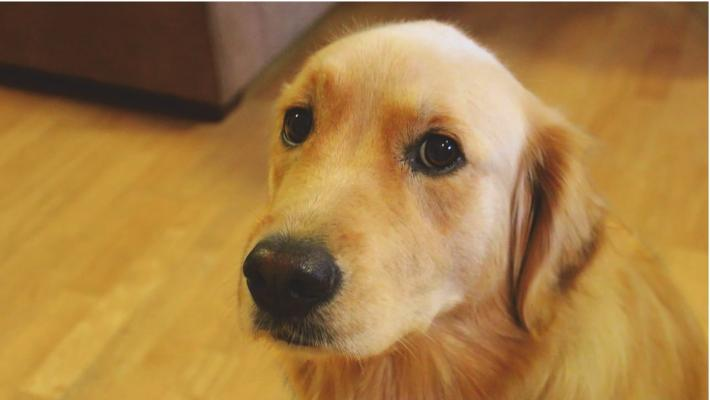

In [18]:
from PIL import Image
img = Image.open("data/bobby.jpg")
img

In [19]:
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)
resnet.eval() # important activate evaluation mode
out = resnet(batch_t)

In [22]:
with open("data/imagenet_classes.txt") as f:
    labels = [line.strip() for line in f.readlines()]
    _, index = torch.max(out, 1)
    percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100

labels[index[0]], percentage[index[0]].item()
_, indices = torch.sort(out, descending=True)
[(labels[idx], percentage[idx].item()) for idx in indices[0][:5]]

[("207: 'golden retriever',", 96.4620590209961),
 ("208: 'Labrador retriever',", 2.910358190536499),
 ("219: 'cocker spaniel, English cocker spaniel, cocker',",
  0.3929084539413452),
 ("852: 'tennis ball',", 0.0643211230635643),
 ("168: 'redbone',", 0.04003051668405533)]